In [1]:
import numpy as np
import os
import mne
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
def parse_sleep_stages(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    events = []

    for e in root.iter("ScoredEvent"):

        concept = e.find("EventConcept").text
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)

        # keep only sleep stages
        if any(x in concept.lower() for x in ["wake", "stage", "rem", "sleep"]):
            events.append((concept, start, duration))

    return events

In [3]:
import numpy as np
import mne
import os
import xml.etree.ElementTree as ET

EPOCH_SIZE = 30  # seconds

# =========================================================
# PATHS
# =========================================================

signal_path = r"C:\Users\DELL\Downloads\Dataset\signals"

annotation_path = r"C:\Users\DELL\Downloads\Dataset\annotations"

# WHERE TO SAVE FINAL DATASET
save_path = r"C:\Users\DELL\Downloads\Dataset\mesa_hr_sleep_dataset.npz"

# =========================================================
# STAGE MAPPING
# =========================================================

def map_stage(text):

    if not text:
        return None

    text = str(text).strip()

    mapping = {

        "Wake|0": 0,

        "Stage 1 sleep|1": 1,

        "Stage 2 sleep|2": 2,

        "Stage 3 sleep|3": 3,

        "Stage 4 sleep|4": 3,

        "REM sleep|5": 4,

        # backup mappings
        "Wake": 0,
        "Stage 1": 1,
        "Stage 2": 2,
        "Stage 3": 3,
        "Stage 4": 3,
        "REM": 4,
    }

    return mapping.get(text)

# =========================================================
# XML PARSER
# =========================================================

def parse_sleep_stages(xml_path):

    try:

        tree = ET.parse(xml_path)

        root = tree.getroot()

    except Exception as e:

        print(f"❌ XML Error {os.path.basename(xml_path)}: {e}")

        return []

    stages = []

    for event in root.iter("ScoredEvent"):

        concept = event.find("EventConcept")

        if concept is None or not concept.text:
            continue

        label = map_stage(concept.text)

        if label is None:
            continue

        duration_elem = event.find("Duration")

        try:
            duration_sec = (
                float(duration_elem.text)
                if duration_elem is not None
                else 30.0
            )

        except:
            duration_sec = 30.0

        n_epochs = max(1, int(duration_sec / EPOCH_SIZE))

        stages.extend([label] * n_epochs)

    return stages

# =========================================================
# FILE LISTS
# =========================================================

signal_files = sorted([
    f for f in os.listdir(signal_path)
    if f.lower().endswith('.edf')
])

annotation_files = sorted([
    f for f in os.listdir(annotation_path)
    if f.lower().endswith('.xml')
])

print(f"Found {len(signal_files)} EDF files")

print(f"Found {len(annotation_files)} XML files")

# =========================================================
# EXTRACTION
# =========================================================

X_all = []

y_all = []

subject_ids = []

for sig_file, ann_file in zip(signal_files, annotation_files):

    try:

        print(f"\nProcessing: {sig_file}")

        raw = mne.io.read_raw_edf(

            os.path.join(signal_path, sig_file),

            preload=False,

            verbose=False
        )

        # -------------------------------------------------
        # CHECK HR CHANNEL
        # -------------------------------------------------

        if "HR" not in raw.ch_names:

            print(f"⚠️ HR channel missing: {sig_file}")

            continue

        # -------------------------------------------------
        # LABELS
        # -------------------------------------------------

        labels = parse_sleep_stages(

            os.path.join(annotation_path, ann_file)
        )

        if len(labels) == 0:

            print(f"⚠️ No labels parsed: {ann_file}")

            continue

        # -------------------------------------------------
        # EPOCH SETTINGS
        # -------------------------------------------------

        sfreq = int(raw.info["sfreq"])

        step = EPOCH_SIZE * sfreq

        n_epochs = min(

            len(labels),

            raw.n_times // step
        )

        # -------------------------------------------------
        # EXTRACT EPOCHS
        # -------------------------------------------------

        for i in range(n_epochs):

            start = i * step

            stop = start + step

            epoch = raw.get_data(

                picks=["HR"],

                start=start,

                stop=stop,

                verbose=False
            )[0]

            if len(epoch) == step:

                X_all.append(
                    epoch.astype(np.float32)
                )

                y_all.append(labels[i])

                subject_ids.append(sig_file)

        print(f"✓ Extracted {n_epochs} epochs")

    except Exception as e:

        print(f"❌ Error {sig_file}: {e}")

# =========================================================
# FINAL ARRAYS
# =========================================================

X_all = np.array(X_all, dtype=np.float32)

y_all = np.array(y_all, dtype=np.int32)

subject_ids = np.array(subject_ids)

# =========================================================
# SUMMARY
# =========================================================

print("\n" + "="*60)

print("✅ EXTRACTION FINISHED")

print("="*60)

print("X shape:", X_all.shape)

print("y shape:", y_all.shape)

print("Subjects:", len(np.unique(subject_ids)))

# =========================================================
# CLASS DISTRIBUTION
# =========================================================

if len(y_all) > 0:

    unique, counts = np.unique(
        y_all,
        return_counts=True
    )

    names = ["Wake", "N1", "N2", "N3", "REM"]

    print("\nClass Distribution:")

    for u, c in zip(unique, counts):

        print(
            f"{u} ({names[u]}): "
            f"{c} epochs"
        )

# =========================================================
# SAVE DATASET
# =========================================================

np.savez_compressed(

    save_path,

    X_all=X_all,

    y_all=y_all,

    subject_ids=subject_ids
)

print("\n" + "="*60)

print("✅ DATASET SAVED SUCCESSFULLY")

print(f"Saved to:\n{save_path}")

print("="*60)

Found 10 EDF files
Found 10 XML files

Processing: mesa-sleep-0001.edf


C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Load

✓ Extracted 1439 epochs

Processing: mesa-sleep-0002.edf


C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Load

✓ Extracted 1319 epochs

Processing: mesa-sleep-0006.edf


...

✓ Extracted 1079 epochs

Processing: mesa-sleep-0027.edf


C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Load

✓ Extracted 1199 epochs

Processing: mesa-sleep-0028.edf


C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  epoch = raw.get_data(
C:\Users\DELL\AppData\Local\Temp\ipykernel_21512\1364228328.py:198: RuntimeWarning: Load

✓ Extracted 1139 epochs

✅ EXTRACTION FINISHED
X shape: (12758, 7680)
y shape: (12758,)
Subjects: 10

Class Distribution:
0 (Wake): 5569 epochs
1 (N1): 942 epochs
2 (N2): 4117 epochs
3 (N3): 869 epochs
4 (REM): 1261 epochs

✅ DATASET SAVED SUCCESSFULLY
Saved to:
C:\Users\DELL\Downloads\Dataset\mesa_hr_sleep_dataset.npz


In [4]:
# =========================================================
#  TRAIN / VAL / TEST SPLIT
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (8930, 7680)
Val  : (1914, 7680)
Test : (1914, 7680)


In [5]:
X = np.asarray(X_all, dtype=np.float32)
y = np.asarray(y_all, dtype=np.int32)

print(X.shape, y.shape)

(12758, 7680) (12758,)


In [6]:
X = (X - np.mean(X)) / np.std(X)

print("Mean after:", np.mean(X))
print("Std after:", np.std(X))

Mean after: 5.770285e-07
Std after: 1.0000021


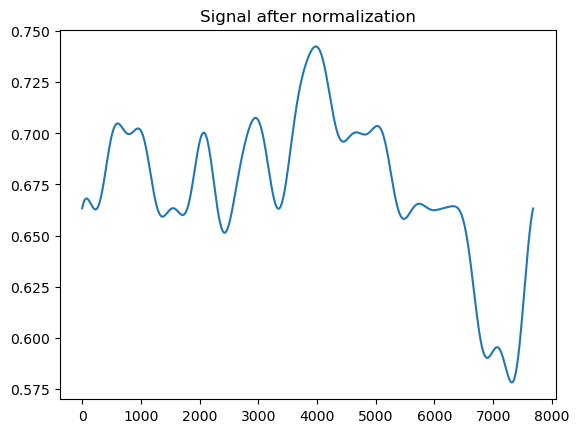

In [7]:
plt.plot(X[0])
plt.title("Signal after normalization")
plt.show()

In [8]:
print(np.unique(y, return_counts=True))

(array([0, 1, 2, 3, 4]), array([5569,  942, 4117,  869, 1261], dtype=int64))


In [30]:
# =========================================================
# LOAD SAVED DATASET
# =========================================================

import numpy as np

load_path = r"C:\Users\DELL\Downloads\Dataset\mesa_hr_sleep_dataset.npz"

data = np.load(load_path, allow_pickle=True)

X_all = data["X_all"]

y_all = data["y_all"]

subject_ids = data["subject_ids"]

print("Dataset loaded successfully")

print("X shape:", X_all.shape)

print("y shape:", y_all.shape)

print("Subjects:", len(np.unique(subject_ids)))

Dataset loaded successfully
X shape: (12758, 7680)
y shape: (12758,)
Subjects: 10


Class Weights: {0: 1.0, 1: 8.5, 2: 1.8, 3: 5.5, 4: 1.4}


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_34                │ (None, 15, 320)        │       163,200 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_35                │ (None, 160)            │       192,960 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 160)            │        25,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 5)              │           805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383,365 (1.46 MB)

 Trainable params: 383,045 (1.46 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.3194 - loss: 3.6341
Epoch 1: val_loss improved from None to 1.32839, saving model to best_n1_focused_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - accuracy: 0.3598 - loss: 3.3684 - val_accuracy: 0.5844 - val_loss: 1.3284 - learning_rate: 0.0015
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.3988 - loss: 2.9896
Epoch 2: val_loss improved from 1.32839 to 1.24889, saving model to best_n1_focused_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.4087 - loss: 2.9666 - val_accuracy: 0.5662 - val_loss: 1.2489 - learning_rate: 0.0015
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.4399 - loss: 2.8782
Epoch 3: val_loss improved from 1.24889 to 1.20976, saving model to best_n1_focused_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.4414 - loss: 2.8201 - val_accuracy: 0.5750 - val_loss: 1.2098 - learning_rate: 0.0015
Epoch 4/150
19/19 ━━━━━━━━━━━━

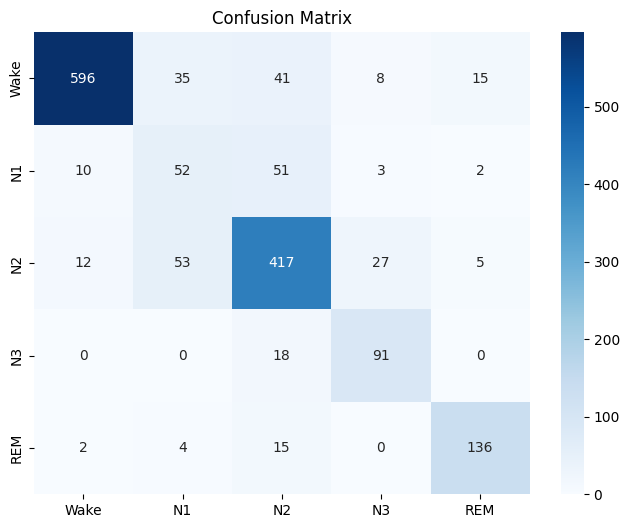

In [33]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# Data Pipeline (unchanged)
# =========================================================
def extract_features(x):
    x = np.asarray(x)
    diff = np.diff(x)
    mean = np.mean(x)
    std = np.std(x)
    rng = np.max(x) - np.min(x)
    rmssd = np.sqrt(np.mean(diff**2)) if len(diff) > 0 else 0
    mad = np.mean(np.abs(diff)) if len(diff) > 0 else 0
    skew = np.mean((x - mean)**3) / (std**3 + 1e-8)
    energy = np.mean(x**2)
    slope = (x[-1] - x[0]) if len(x) > 1 else 0
   
    return np.array([mean, std, rng, rmssd, mad, energy, skew, slope], dtype=np.float32)

X_feat = np.array([extract_features(x) for x in X_all], dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

SEQ_LEN = 15
X_seq, y_seq = [], []
for i in range(len(X_feat) - SEQ_LEN):
    X_seq.append(X_feat[i:i+SEQ_LEN])
    y_seq.append(y_all[i + SEQ_LEN // 2])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.25, stratify=y_seq, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

mean = X_train.mean(axis=(0,1))
std = X_train.std(axis=(0,1)) + 1e-8
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# =========================================================
# VERY AGGRESSIVE WEIGHTS - Heavy boost for N1
# =========================================================
class_weights = {
    0: 1.0,    # Wake
    1: 8.5,    # N1     ← Extremely boosted
    2: 1.8,    # N2
    3: 5.5,    # N3
    4: 1.4     # REM
}

print("Class Weights:", class_weights)

# =========================================================
# MODEL
# =========================================================
tf.keras.mixed_precision.set_global_policy('mixed_float16')

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQ_LEN, X_train.shape[2])),
   
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(160, return_sequences=True, dropout=0.15)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(80, return_sequences=False, dropout=0.15)),
   
    tf.keras.layers.Dense(160, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.32),
   
    tf.keras.layers.Dense(5, activation='softmax', dtype='float32')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0015, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# TRAINING
# =========================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_n1_focused_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=512,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# =========================================================
# FINAL EVALUATION
# =========================================================
loss, acc = model.evaluate(X_test, y_test)
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(f"Overall Accuracy : {acc:.4f} | Loss: {loss:.5f}\n")
print(classification_report(y_test, y_pred, 
                           target_names=["Wake", "N1", "N2", "N3", "REM"], digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Wake", "N1", "N2", "N3", "REM"],
            yticklabels=["Wake", "N1", "N2", "N3", "REM"])
plt.title('Confusion Matrix')
plt.show()

In [36]:
model.save("sleep_staging_model.keras")